## Utility functions used through out the code 

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from typing import List,Tuple
from collections import defaultdict

np.random.seed(42)
torch.manual_seed(42)
#loader fn 
# Utility functions 
def rat_loader(path):
    fl = []
    with open(path,'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                fl.append((int(parts[0]),int(parts[1]),float(parts[2])))
    return fl

def matrix_makier(base_path,test_path):
    tr_dt = rat_loader(base_path)
    tst_dt = rat_loader(test_path)
    full_dt = tr_dt + tst_dt
    max_u = max(u for u,i,r in full_dt)
    max_i = max(i for u,i,r in full_dt)
    fl_mat = np.zeros((max_u,max_i))
    for u,i,r in tr_dt:
        fl_mat[u-1,i-1] = r
    t_lst = [(u-1,i-1,r) for u,i,r in tst_dt]
    return fl_mat,t_lst,max_u,max_i

def compute_baseline(R):
    mask = R > 0
    mu = R[mask].mean() if mask.sum() > 0 else 3.0
    n_u,n_i = R.shape
    bu = np.zeros(n_u)
    bi = np.zeros(n_i)
    for _ in range(10):
        for u in range(n_u):
            items = np.where(mask[u])[0]
            if items.size > 0:
                bu[u] = (R[u,items] - mu - bi[items]).mean()
        for i in range(n_i):
            users = np.where(mask[:,i])[0]
            if users.size > 0:
                bi[i] = (R[users,i] - mu - bu[users]).mean()
    return mu,bu,bi

#final_metrics fn yeh assume kiya hai maine nmae is max-min normalized hai 
def metrics(preds,real):
    err = np.array(preds) - np.array(real)
    mae = np.abs(err).mean()
    rmse = np.sqrt((err**2).mean())
    nmae = mae/4.0
    return nmae,mae,rmse


## User-Based Collaborative Filtering

This class implements a user-based collaborative filtering algorithm with the following features:

- **Similarity computation**: Calculates user-user similarity based on centered ratings (residuals)
- **Shrinkage**: Applies shrinkage parameter to penalize similarities based on few co-rated items
- **K-nearest padosi**: Selects top-k similar users for prediction
- **Confidence scoring**: Returns prediction confidence based on similarity weights

The algorithm predicts ratings by finding similar users who have rated the target item and aggregating their preferences weighted by similarity scores.

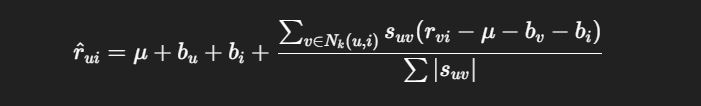
Used this formula credits for image ChatGPT 

In [ ]:
class UserBasedCF:
    def __init__(self,R,mu,bu,bi,k=40,shrink=25,min_sim=0.0):
        self.R = R.astype(np.float32)
        self.mu = float(mu) # global mean of all rat 
        self.bu = bu.astype(np.float32) # user ka bias 
        self.bi = bi.astype(np.float32) # item ka bias 
        self.k = int(k) # neighbous ka number isse mai hyperparameter ke roop mai use karunga 
        self.shrink = float(shrink) # similarity shrinkage factor
        self.min_sim = float(min_sim) # minimum similarity threshold
        self.mask = self.R > 0 # mask for observed ratings to speed up agr mapping saved ha
        self.resid = self.R - (self.mu + self.bu[:,None] + self.bi[None,:]).astype(np.float32) # residual matrix 
        self.resid[~self.mask] = 0 # set unobserved ratings to zero
        norms = np.linalg.norm(self.resid,axis=1) + 1e-9 # user norms with small epsilon to avoid div by zero
        sim_base = (self.resid @ self.resid.T) / (norms[:,None]*norms[None,:])
        self.sim_base = sim_base.astype(np.float32)
        np.fill_diagonal(self.sim_base,0)
        self.overlap = (self.mask @ self.mask.T).astype(np.int32)
        self.users_by_item = [np.where(self.mask[:,i])[0] for i in range(self.R.shape[1])]
    
    def padosi(self,u,i): # this function finds top k jo uppar liya hai 
        usr_cls = self.users_by_item[i]
        if usr_cls.size == 0: # erro handling 
            return np.array([]),np.array([])
        sims = self.sim_base[u,usr_cls]*(np.minimum(self.overlap[u,usr_cls],self.shrink)/self.shrink)
        if self.min_sim > 0:
            keep = sims >= self.min_sim
            usr_cls = usr_cls[keep]
            sims = sims[keep]
        if sims.size == 0:
            return np.array([]),np.array([])
        top_idx = np.argsort(-np.abs(sims))[:self.k]
        return usr_cls[top_idx],sims[top_idx]

    def cof_prdt(self,u,i):
        base = self.mu + self.bu[u] + self.bi[i]
        usr_cls,sims = self.padosi(u,i)
        if sims.size == 0:
            return np.clip(base,1,5),0.0
        denom = np.abs(sims).sum()
        if denom < 1e-9:
            # print("Trigger")
            return np.clip(base,1,5),0.0
        delta = (sims*self.resid[usr_cls,i]).sum()/denom
        # print(delta)
        return np.clip(base + delta,1,5),float(denom)

    def predict(self,u,i):
        pred = self.cof_prdt(u,i)
        # print(pred)
        return pred[0]


## Item-Based Collaborative Filtering

- Computes **item–item similarity** using bias-centered ratings (residuals)
- Uses **cosine similarity** with **shrinkage** to penalize low co-rating counts
- Selects **top-k similar items** rated by the user
- Predicts ratings using a **weighted sum of residuals**
- Returns a **confidence score** based on total similarity weight

**Prediction formula:**

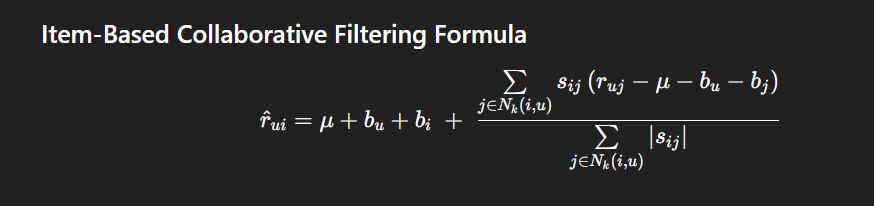
Formula credits to ChatGPT

In [ ]:
import os
import numpy as np


base_dir = os.path.join("archive","ml-100k")
folds = [1,2,3,4,5]
K = 40
shrink = 25
min_sim = 0.0


fold_scores = []

for fold in folds:
    base_path = os.path.join(base_dir,f"u{fold}.base")
    test_path = os.path.join(base_dir,f"u{fold}.test")


    R,t_lst,n_u,n_i = matrix_makier(base_path,test_path)
    mu,bu,bi = compute_baseline(R)


    user_cf = UserBasedCF(R,mu,bu,bi,k=K,shrink=shrink,min_sim=min_sim)

 
    preds = [user_cf.predict(u,i) for (u,i,r) in t_lst]
    real = [r for (_,_,r) in t_lst]

    nmae,mae,rmse = metrics(preds,real)
    fold_scores.append((nmae,mae,rmse))
    print(f"Fold u{fold}: NMAE={nmae:.6f},MAE={mae:.6f},RMSE={rmse:.6f}")

# averages over folds
avg_nmae = float(np.mean([s[0] for s in fold_scores]))
avg_mae  = float(np.mean([s[1] for s in fold_scores]))
avg_rmse = float(np.mean([s[2] for s in fold_scores]))

print("\n=== AVERAGE (UserBasedCF) ===")
print(f"Avg NMAE: {avg_nmae:.6f}")
print(f"Avg MAE:  {avg_mae:.6f}")
print(f"Avg RMSE: {avg_rmse:.6f}")

NameError: name 'matrix_makier' is not defined

In [ ]:
class ItemBasedCF:
    def __init__(self,R,mu,bu,bi,k=40,shrink=25,min_sim=0.0):
        self.R = R.astype(np.float32) # rating matrix
        self.mu = float(mu) # global mean of all rat
        self.bu = bu.astype(np.float32) # user ka bias
        self.bi = bi.astype(np.float32) # item ka bias
        self.k = int(k) # number of neighbors
        self.shrink = float(shrink) # similarity shrinkage factor
        self.min_sim = float(min_sim)   # minimum similarity threshold
        self.mask = self.R > 0 # mask for observed ratings
        self.resid = self.R - (self.mu + self.bu[:,None] + self.bi[None,:]).astype(np.float32) # residual matrix
        self.resid[~self.mask] = 0 # set unobserved ratings to zero
        R_t = self.resid.T 
        norms = np.linalg.norm(R_t,axis=1) + 1e-9
        sim_base = (R_t @ R_t.T) / (norms[:,None]*norms[None,:])
        self.sim_base = sim_base.astype(np.float32)
        np.fill_diagonal(self.sim_base,0)
        self.overlap = (self.mask.T @ self.mask).astype(np.int32)
        self.items_by_user = [np.where(self.mask[u])[0] for u in range(self.R.shape[0])]
    
    def padosi(self,u,i):
        usr_cls = self.items_by_user[u]
        if usr_cls.size == 0:
            return np.array([]),np.array([])
        sims = self.sim_base[i,usr_cls]*(np.minimum(self.overlap[i,usr_cls],self.shrink) / self.shrink)
        if self.min_sim > 0:
            keep = sims >= self.min_sim
            usr_cls = usr_cls[keep]
            sims = sims[keep]
        if sims.size == 0:
            return np.array([]),np.array([])
        top_idx = np.argsort(-np.abs(sims))[:self.k]
        return usr_cls[top_idx],sims[top_idx]

    def cof_prdt(self,u,i):
        base = self.mu + self.bu[u] + self.bi[i]
        usr_cls,sims = self.padosi(u,i)
        if sims.size == 0:
            return np.clip(base,1,5),0.0
        denom = np.abs(sims).sum()
        if denom < 1e-9:
            return np.clip(base,1,5),0.0
        delta = (sims*self.resid[u,usr_cls]).sum() / denom
        return np.clip(base + delta,1,5),float(denom)

    def predict(self,u,i):
        pred,_ = self.cof_prdt(u,i)
        return pred


In [ ]:
import os
import numpy as np

base_dir = os.path.join("archive","ml-100k")
folds = [1,2,3,4,5]
K = 40
shrink = 25
min_sim = 0.0

fold_scores = []

for fold in folds:
    base_path = os.path.join(base_dir,f"u{fold}.base")
    test_path = os.path.join(base_dir,f"u{fold}.test")

    R,t_lst,n_u,n_i = matrix_makier(base_path,test_path)
    mu,bu,bi = compute_baseline(R)

    user_cf = ItemBasedCF(R,mu,bu,bi,k=K,shrink=shrink,min_sim=min_sim)

    preds = [user_cf.predict(u,i) for (u,i,r) in t_lst]
    real = [r for (_,_,r) in t_lst]


    nmae,mae,rmse = metrics(preds,real)
    fold_scores.append((nmae,mae,rmse))
    print(f"Fold u{fold}: NMAE={nmae:.6f},MAE={mae:.6f},RMSE={rmse:.6f}")

# averages 
avg_nmae = float(np.mean([s[0] for s in fold_scores]))
avg_mae  = float(np.mean([s[1] for s in fold_scores]))
avg_rmse = float(np.mean([s[2] for s in fold_scores]))

print("\n=== AVERAGE (ItemBasedCF) ===")
print(f"Avg NMAE: {avg_nmae:.6f}")
print(f"Avg MAE:  {avg_mae:.6f}")
print(f"Avg RMSE: {avg_rmse:.6f}")

Fold u1: NMAE=0.181707, MAE=0.726830, RMSE=0.930370
Fold u2: NMAE=0.178981, MAE=0.715923, RMSE=0.918691
Fold u3: NMAE=0.178928, MAE=0.715714, RMSE=0.916686
Fold u4: NMAE=0.179080, MAE=0.716322, RMSE=0.917175
Fold u5: NMAE=0.180248, MAE=0.720992, RMSE=0.917995

=== AVERAGE (ItemBasedCF) ===
Avg NMAE: 0.179789
Avg MAE:  0.719156
Avg RMSE: 0.920183


In [ ]:
class WeightedHybrid:
    def __init__(self,user_cf,item_cf,wt_adi=0.5,mode='fixed'):
        self.user_cf = user_cf
        self.item_cf = item_cf
        self.wt_adi = wt_adi
        self.mode = mode  # 2 choices 'fixed' or 'conf' 
    
    def predict(self,u,i):
        p_user,c_user = self.user_cf.cof_prdt(u,i)
        p_item,c_item = self.item_cf.cof_prdt(u,i)
        if self.mode == 'conf':
            denom = c_user + c_item
            if denom > 0:
                wt_adi = c_user / denom
            else:
                wt_adi = 0.5
        else:
            wt_adi = self.wt_adi
        return wt_adi*p_user + (1-wt_adi)*p_item

### Summary of Optuna Experiments

- Neighborhood CF used **bias-corrected residuals**,cosine similarity with **shrinkage**,**top-k neighbors**,and a **min_sim** threshold.
- Three hybrids were tested with Optuna tuning: **WeightedHybrid**,**AdaptiveHybrid (hard/soft/conf)**,and **Adaptive CF + Content-Based (CBF)**.
- **Confidence-based weighting** (using summed absolute similarities as confidence) consistently performed well and was selected by Optuna.
- **Optuna (TPESampler + MedianPruner)** enabled robust tuning of neighborhood size,shrinkage,thresholds,and mixing weights across all models.

In [ ]:

import os
import optuna
import numpy as np


base_dir = os.path.join('archive','ml-100k')
folds = [1,2,3,4,5]
N_TRIALS = 50
RANDOM_SEED = 42


def main_fn(trial):
    K = trial.suggest_int("K",20,150,step=20)
    shrink = trial.suggest_int("shrink",10,80,step=5)          
    min_sim = trial.suggest_float("min_sim",0.0,0.1)
    wt_adi = trial.suggest_float("wt_adi",0.1,0.9)
    mode = trial.suggest_categorical("mode",["fixed","conf"])
    fold_nmaes = []

    for fold in folds:
        base_path = os.path.join(base_dir,f'u{fold}.base')
        test_path = os.path.join(base_dir,f'u{fold}.test')
        R,t_lst,n_u,n_i = matrix_makier(base_path,test_path)
        mu,bu,bi = compute_baseline(R)

        # build models with trial hyperparams
        user_cf = UserBasedCF(R,mu,bu,bi,k=K,shrink=shrink,min_sim=min_sim)
        item_cf = ItemBasedCF(R,mu,bu,bi,k=K,shrink=shrink,min_sim=min_sim)
        hybrid = WeightedHybrid(user_cf,item_cf,wt_adi=wt_adi,mode=mode)

        # predict on t_lst
        preds = [hybrid.predict(u,i) for (u,i,r) in t_lst]
        real = [r for (_,_,r) in t_lst]

        nmae,mae,rmse = metrics(preds,real)
        fold_nmaes.append(nmae)

        trial.report(float(np.mean(fold_nmaes)),step=fold)
        if trial.should_prune():
            # agr prune hua to 
            raise optuna.TrialPruned()
    return float(np.mean(fold_nmaes))



# Sampler defined To work 
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
# Tpe use kiya kyu ki provide pruning to search space thoda chhota hogya 
pruner = optuna.pruners.MedianPruner(n_startup_trials=5,n_warmup_steps=1)
wrk_by_adi = optuna.create_study(direction="minimize",sampler=sampler,pruner=pruner)

try:
    wrk_by_adi.optimize(main_fn,n_trials=N_TRIALS,show_progress_bar=True)
except KeyboardInterrupt:
    print("Kharab hogya")

# Best params
best_params = wrk_by_adi.best_params

for k,v in best_params.items():
    print(f"{k}: {v}")

best_K = int(best_params.get("K"))
best_shrink = int(best_params.get("shrink"))
best_min_sim = float(best_params.get("min_sim"))
best_alpha = float(best_params.get("wt_adi"))
best_mode = best_params.get("mode")

final_reslts = []
for fold in folds:
    base_path = os.path.join(base_dir,f'u{fold}.base')
    test_path = os.path.join(base_dir,f'u{fold}.test')

    R,t_lst,n_u,n_i = matrix_makier(base_path,test_path)
    mu,bu,bi = compute_baseline(R) # baseline comp kr rha 

    user_cf = UserBasedCF(R,mu,bu,bi,k=best_K,shrink=best_shrink,min_sim=best_min_sim)
    item_cf = ItemBasedCF(R,mu,bu,bi,k=best_K,shrink=best_shrink,min_sim=best_min_sim)
    hybrid = WeightedHybrid(user_cf,item_cf,wt_adi=best_alpha,mode=best_mode)

    preds = [hybrid.predict(u,i) for (u,i,r) in t_lst]
    real = [r for (_,_,r) in t_lst]

    final_reslts.append(metrics(preds,real))

avg_nmae = float(np.mean([s[0] for s in final_reslts]))
avg_mae = float(np.mean([s[1] for s in final_reslts]))
avg_rmse = float(np.mean([s[2] for s in final_reslts]))

print("Final performance with best hyperparameters")
print(f"Average NMAE: {avg_nmae:.6f}")
print(f"Average MAE:  {avg_mae:.6f}")
print(f"Average RMSE: {avg_rmse:.6f}\n")

print("Per-fold metrics (NMAE,MAE,RMSE):")
for idx,(nmae,mae,rmse) in enumerate(final_reslts,start=1):
    print(f"Fold u{idx}: {nmae:.6f},{mae:.6f},{rmse:.6f}")

[I 2026-01-30 19:53:18,789] A new study created in memory with name: no-name-4d15ad35-2b04-4d02-9228-0bcfa8901816


Starting Optuna study for 50 trials...


Best trial: 0. Best value: 0.185827:   2%|▏         | 1/50 [00:10<08:15, 10.11s/it]

[I 2026-01-30 19:53:28,900] Trial 0 finished with value: 0.18582664358049633 and parameters: {'K': 60, 'shrink': 80, 'min_sim': 0.0731993941811405, 'alpha': 0.5789267873576293, 'mode': 'fixed'}. Best is trial 0 with value: 0.18582664358049633.


Best trial: 1. Best value: 0.185827:   4%|▍         | 2/50 [00:20<08:01, 10.03s/it]

...

[I 2026-01-30 20:00:16,421] Trial 47 pruned. 


Best trial: 24. Best value: 0.17929:  98%|█████████▊| 49/50 [06:59<00:03,  3.99s/it]

[I 2026-01-30 20:00:18,773] Trial 48 pruned. 


Best trial: 24. Best value: 0.17929: 100%|██████████| 50/50 [07:02<00:00,  8.45s/it]


[I 2026-01-30 20:00:21,164] Trial 49 pruned. 

=== Best hyperparameters (Optuna) ===
K: 140
shrink: 55
min_sim: 0.0008066302723931358
alpha: 0.49187687068808117
mode: conf

=== Final performance with best hyperparameters ===
Average NMAE: 0.179290
Average MAE:  0.717161
Average RMSE: 0.917595

Per-fold metrics (NMAE, MAE, RMSE):
Fold u1: 0.180896, 0.723586, 0.927349
Fold u2: 0.178507, 0.714030, 0.916388
Fold u3: 0.178602, 0.714409, 0.914028
Fold u4: 0.178560, 0.714241, 0.914718
Fold u5: 0.179885, 0.719538, 0.915491


In [ ]:
import numpy as np
import os

class AdaptiveHybridRecommender:
    def __init__(self,user_cf,item_cf,rating_threshold=50,k_ub=20,k_ib=20,mode='soft',eps=1e-6):
        self.user_cf = user_cf  # user-based CF model
        self.item_cf = item_cf # item-based CF model
        self.rating_threshold = rating_threshold # threshold for switching
        self.k_ub = k_ub
        self.k_ib = k_ib
        self.mode = mode
        self.eps = float(eps)

    def f_predict(self,model,u,i):
        return float(model.predict(u,i)),0.0
    def rat_ct(self,id_ur):
        if hasattr(self.user_cf,"mask"):
            try:
                return int(np.count_nonzero(self.user_cf.mask[id_ur,:]))
            except Exception:
                pass
        if hasattr(self.user_cf,"R"):
            try:
                return int(np.count_nonzero(self.user_cf.R[id_ur,:]))
            except Exception:
                pass
        return 0

    def predict(self,id_ur,item_id):
        p_user,c_user = self.f_predict(self.user_cf,id_ur,item_id)
        p_item,c_item = self.f_predict(self.item_cf,id_ur,item_id)# simple predict chla diya 
        p_user = float(p_user); p_item = float(p_item)
        c_user = float(c_user) if c_user is not None else 0.0
        c_item = float(c_item) if c_item is not None else 0.0
        c_user = max(0.0,c_user); c_item = max(0.0,c_item)

        if self.mode == 'hard':
            cnt = self.rat_ct(id_ur)
            if cnt < self.rating_threshold:
                return float(np.clip(p_item,1.0,5.0))
            else:
                return float(np.clip(p_user,1.0,5.0))

        elif self.mode == 'soft':
            cnt = self.rat_ct(id_ur)
            w_user = float(min(1.0,cnt / float(self.rating_threshold)))
            pred = w_user*p_user + (1.0 - w_user)*p_item
            return float(np.clip(pred,1.0,5.0))

        else:
            denom = c_user + c_item + self.eps
            if denom <= self.eps:
                pred = 0.5*(p_user + p_item)
            else:
                wt_adi = c_user / denom
                pred = wt_adi*p_user + (1.0 - wt_adi)*p_item
            return float(np.clip(pred,1.0,5.0))


In [ ]:

import os
import optuna
import numpy as np

base_dir = os.path.join('archive','ml-100k')
folds = [1,2,3,4,5]
N_TRIALS = 100
SEED = 42

# suggest_k func documentation me hai 
def main_fn(trial):

    mode = trial.suggest_categorical("mode",["hard","soft","conf"])
    rating_threshold = trial.suggest_int("rating_threshold",20,80,step=10)

    K = trial.suggest_int("K",30,60,step=10)
    shrink = trial.suggest_int("shrink",25,75,step=25)
    min_sim = trial.suggest_categorical("min_sim",[0.0,0.05])

    fold_nmae = []

    for fold in folds:
        base_path = os.path.join(base_dir,f'u{fold}.base')
        test_path = os.path.join(base_dir,f'u{fold}.test')

        R,t_lst,n_u,n_i = matrix_makier(base_path,test_path)
        mu,bu,bi = compute_baseline(R)


        user_cf = UserBasedCF(
            R,mu,bu,bi,
            k=K,shrink=shrink,min_sim=min_sim
        )

        item_cf = ItemBasedCF(
            R,mu,bu,bi,
            k=K,shrink=shrink,min_sim=min_sim
        )

        hybrid = AdaptiveHybridRecommender(
            user_cf,
            item_cf,
            rating_threshold=rating_threshold,
            k_ub=K,
            k_ib=K,
            mode=mode
        )

        preds = [hybrid.predict(u,i) for (u,i,r) in t_lst]
        real = [r for (_,_,r) in t_lst]

        nmae,mae,rmse = metrics(preds,real)
        fold_nmae.append(nmae)


        trial.report(float(np.mean(fold_nmae)),step=fold)
        if trial.should_prune():
            # prune called 
            raise optuna.TrialPruned()
            
    return float(np.mean(fold_nmae))



sampler = optuna.samplers.TPESampler(seed=SEED)
pruner = optuna.pruners.MedianPruner(
    n_startup_trials=5,
    n_warmup_steps=1
)

wrk_by_adi = optuna.create_study(
    direction="minimize",
    sampler=sampler,
    pruner=pruner
)


wrk_by_adi.optimize(main_fn,n_trials=N_TRIALS,show_progress_bar=True)


for k,v in wrk_by_adi.best_params.items():
    print(f"{k}: {v}")

bp = wrk_by_adi.best_params
scores = []

for fold in folds:
    base_path = os.path.join(base_dir,f'u{fold}.base')
    test_path = os.path.join(base_dir,f'u{fold}.test')

    R,t_lst,n_u,n_i = matrix_makier(base_path,test_path)
    mu,bu,bi = compute_baseline(R)

    user_cf = UserBasedCF(
        R,mu,bu,bi,
        k=bp["K"],
        shrink=bp["shrink"],
        min_sim=bp["min_sim"]
    )

    item_cf = ItemBasedCF(
        R,mu,bu,bi,
        k=bp["K"],
        shrink=bp["shrink"],
        min_sim=bp["min_sim"]
    )

    hybrid = AdaptiveHybridRecommender(
        user_cf,
        item_cf,
        rating_threshold=bp["rating_threshold"],
        k_ub=bp["K"],
        k_ib=bp["K"],
        mode=bp["mode"]
    )

    preds = [hybrid.predict(u,i) for (u,i,r) in t_lst]
    real = [r for (_,_,r) in t_lst]
    scores.append(metrics(preds,real))

print("\n=== FINAL PERFORMANCE ===")
print(f"Avg NMAE: {np.mean([s[0] for s in scores]):.6f}")
print(f"Avg MAE:  {np.mean([s[1] for s in scores]):.6f}")
print(f"Avg RMSE: {np.mean([s[2] for s in scores]):.6f}")

print("\nPer-fold metrics:")
for i,(nmae,mae,rmse) in enumerate(scores,1):
    print(f"Fold u{i}: {nmae:.6f},{mae:.6f},{rmse:.6f}")

[I 2026-01-30 20:26:41,096] A new study created in memory with name: no-name-2c6dd2a6-839a-475c-aca0-3ea23d98e03d


Running Optuna Adaptive Hybrid for 100 trials...


Best trial: 0. Best value: 0.185827:   1%|          | 1/100 [00:11<19:35, 11.88s/it]

[I 2026-01-30 20:26:52,969] Trial 0 finished with value: 0.1858266435083747 and parameters: {'mode': 'soft', 'rating_threshold': 60, 'K': 30, 'shrink': 25, 'min_sim': 0.05}. Best is trial 0 with value: 0.1858266435083747.


Best trial: 0. Best value: 0.185827:   2%|▏         | 2/100 [00:23<18:43, 11.46s/it]

...

[I 2026-01-30 20:46:54,576] Trial 97 finished with value: 0.17974989280421655 and parameters: {'mode': 'conf', 'rating_threshold': 40, 'K': 30, 'shrink': 75, 'min_sim': 0.0}. Best is trial 18 with value: 0.17974989280421655.


Best trial: 18. Best value: 0.17975:  99%|█████████▉| 99/100 [20:31<00:17, 17.80s/it]

[I 2026-01-30 20:47:13,046] Trial 98 finished with value: 0.17974989280421655 and parameters: {'mode': 'conf', 'rating_threshold': 30, 'K': 30, 'shrink': 75, 'min_sim': 0.0}. Best is trial 18 with value: 0.17974989280421655.


Best trial: 18. Best value: 0.17975: 100%|██████████| 100/100 [20:36<00:00, 12.36s/it]


[I 2026-01-30 20:47:17,428] Trial 99 pruned. 

=== BEST HYPERPARAMETERS (Adaptive Hybrid) ===
mode: conf
rating_threshold: 40
K: 30
shrink: 75
min_sim: 0.0

=== FINAL PERFORMANCE ===
Avg NMAE: 0.179750
Avg MAE:  0.719000
Avg RMSE: 0.919939

Per-fold metrics:
Fold u1: 0.181552, 0.726207, 0.929633
Fold u2: 0.178914, 0.715658, 0.918972
Fold u3: 0.178967, 0.715869, 0.916611
Fold u4: 0.179308, 0.717230, 0.918041
Fold u5: 0.180008, 0.720033, 0.916439


In [ ]:
import numpy as np
import os

class ContentBased:
    def __init__(self,R,mu,bu,bi,item_features,k=20,min_sim=0.0):
        self.R = R.astype(np.float32)
        self.mu = float(mu)
        self.bu = bu.astype(np.float32)
        self.bi = bi.astype(np.float32)
        self.k = int(k)
        self.min_sim = float(min_sim)

        self.mask = self.R > 0
        self.resid = self.R - (self.mu + self.bu[:,None] + self.bi[None,:]).astype(np.float32)
        self.resid[~self.mask] = 0.0

        F = item_features[:self.R.shape[1]].astype(np.float32)
        F /= (np.linalg.norm(F,axis=1,keepdims=True) + 1e-9)

        self.sim = (F @ F.T).astype(np.float32)
        np.fill_diagonal(self.sim,0.0)

        self.items_by_user = [np.where(self.mask[u])[0] for u in range(self.R.shape[0])]

    def predict(self,u,i):
        base = self.mu + self.bu[u] + self.bi[i]
        rated = self.items_by_user[u]
        if rated.size == 0:
            return np.clip(base,1,5)

        sims = self.sim[i,rated]
        if self.min_sim > 0:
            keep = sims >= self.min_sim
            rated,sims = rated[keep],sims[keep]

        if sims.size == 0:
            return np.clip(base,1,5)

        top = np.argsort(-np.abs(sims))[:self.k]
        sims = sims[top]
        rated = rated[top]

        denom = np.abs(sims).sum()
        if denom < 1e-9:
            return np.clip(base,1,5)

        delta = (sims*self.resid[u,rated]).sum() / denom
        return np.clip(base + delta,1,5)

def load_ml100k_item_features(base_dir):
    feats = []
    with open(os.path.join(base_dir,"u.item"),encoding="latin-1") as f:
        for line in f:
            parts = line.strip().split("|")
            feats.append([int(x) for x in parts[-19:]])
    return np.array(feats,dtype=np.float32)
class AdaptiveCFplusCBF:
    def __init__(self,adaptive_cf,cbf,w_cbf=0.3):
        self.adaptive_cf = adaptive_cf
        self.cbf = cbf
        self.w_cbf = float(w_cbf)

    def predict(self,u,i):
        cf = self.adaptive_cf.predict(u,i)
        cbf = self.cbf.predict(u,i)
        return np.clip((1 - self.w_cbf)*cf + self.w_cbf*cbf,1,5)
import optuna

def adaptive_cbf(base_dir="archive/ml-100k",n_trials=40,seed=42):
    item_features = load_ml100k_item_features(base_dir)
    folds = [1,2,3,4,5]
    def main_fn(trial):
        # Adaptive CF params
        mode = trial.suggest_categorical("mode",["hard","soft","conf"])
        rating_threshold = trial.suggest_int("rating_threshold",20,80,step=10)

        K = trial.suggest_int("K",30,70,step=10)
        shrink = trial.suggest_int("shrink",25,75,step=25)
        min_sim = trial.suggest_categorical("min_sim",[0.0,0.05])

        # CBF params
        cbf_k = trial.suggest_int("cbf_k",10,50,step=10)
        w_cbf = trial.suggest_float("w_cbf",0.0,0.8)

        fold_nmae = []

        for fold in folds:
            R,t_lst,_,_ = matrix_makier(os.path.join(base_dir,f"u{fold}.base"),os.path.join(base_dir,f"u{fold}.test")
            )
            mu,bu,bi = compute_baseline(R)
            user_cf = UserBasedCF(R,mu,bu,bi,k=K,shrink=shrink,min_sim=min_sim)
            item_cf = ItemBasedCF(R,mu,bu,bi,k=K,shrink=shrink,min_sim=min_sim)
            adaptive_cf = AdaptiveHybridRecommender(user_cf,item_cf,rating_threshold=rating_threshold,k_ub=K,k_ib=K,mode=mode
            )
            cbf = ContentBased(R,mu,bu,bi,item_features,k=cbf_k,min_sim=min_sim)

            model = AdaptiveCFplusCBF(adaptive_cf,cbf,w_cbf=w_cbf)

            preds = [model.predict(u,i) for u,i,r in t_lst]
            real = [r for _,_,r in t_lst]

            nmae,_,_ = metrics(preds,real)
            fold_nmae.append(nmae)

            trial.report(np.mean(fold_nmae),fold)
            if trial.should_prune():
                raise optuna.TrialPruned()

        return float(np.mean(fold_nmae))

    wrk_by_adi = optuna.create_study(direction="minimize",sampler=optuna.samplers.TPESampler(seed=seed),pruner=optuna.pruners.MedianPruner()
    )

    wrk_by_adi.optimize(main_fn,n_trials=n_trials,show_progress_bar=True)

    for k,v in wrk_by_adi.best_params.items():
        print(f"{k}: {v}")

    bp = wrk_by_adi.best_params
    folds = [1,2,3,4,5]

    scores_cf = []      # Adaptive CF only
    scores_cbf = []     # CBF only
    scores_hybrid = []  # Adaptive CF + CBF

    for fold in folds:
        R,t_lst,_,_ = matrix_makier(
            os.path.join(base_dir,f"u{fold}.base"),
            os.path.join(base_dir,f"u{fold}.test")
        )
        mu,bu,bi = compute_baseline(R)

        user_cf = UserBasedCF(
            R,mu,bu,bi,
            k=bp["K"],
            shrink=bp["shrink"],
            min_sim=bp["min_sim"]
        )
        item_cf = ItemBasedCF(
            R,mu,bu,bi,
            k=bp["K"],
            shrink=bp["shrink"],
            min_sim=bp["min_sim"]
        )

        adaptive_cf = AdaptiveHybridRecommender(
            user_cf,
            item_cf,
            rating_threshold=bp["rating_threshold"],
            k_ub=bp["K"],
            k_ib=bp["K"],
            mode=bp["mode"]
        )

        preds_cf = [adaptive_cf.predict(u,i) for u,i,r in t_lst]
        real = [r for _,_,r in t_lst]
        scores_cf.append(metrics(preds_cf,real))


        cbf = ContentBased(
            R,mu,bu,bi,
            item_features,
            k=bp["cbf_k"],
            min_sim=bp["min_sim"]
        )

        preds_cbf = [cbf.predict(u,i) for u,i,r in t_lst]
        scores_cbf.append(metrics(preds_cbf,real))

        hybrid = AdaptiveCFplusCBF(
            adaptive_cf,
            cbf,
            w_cbf=bp["w_cbf"]
        )

        preds_hybrid = [hybrid.predict(u,i) for u,i,r in t_lst]
        scores_hybrid.append(metrics(preds_hybrid,real))

    def print_results(name,scores):
        print(f"\n=== {name} ===")
        for i,(nmae,mae,rmse) in enumerate(scores,1):
            print(f"Fold u{i}: NMAE={nmae:.6f},MAE={mae:.6f},RMSE={rmse:.6f}")
        print(f"AVG: NMAE={np.mean([s[0] for s in scores]):.6f},"
              f"MAE={np.mean([s[1] for s in scores]):.6f},"
              f"RMSE={np.mean([s[2] for s in scores]):.6f}")
    print_results("Adaptive CF only",scores_cf)
    print_results("CBF only",scores_cbf)
    print_results("Adaptive CF + CBF (Hybrid)",scores_hybrid)
    return wrk_by_adi
adaptive_cbf(n_trials=100)

[I 2026-01-30 21:27:40,730] A new study created in memory with name: no-name-d56b30de-177f-479a-bb5a-b3e57010f6cd
Best trial: 0. Best value: 0.183626:   1%|          | 1/100 [00:14<24:01, 14.56s/it]

[I 2026-01-30 21:27:55,289] Trial 0 finished with value: 0.18362553045660257 and parameters: {'mode': 'soft', 'rating_threshold': 60, 'K': 30, 'shrink': 25, 'min_sim': 0.05, 'cbf_k': 40, 'w_cbf': 0.5664580622368364}. Best is trial 0 with value: 0.18362553045660257.


Best trial: 0. Best value: 0.183626:   2%|▏         | 2/100 [00:29<23:58, 14.67s/it]

[I 2026-01-30 21:28:10,042] Trial 1 finished with value: 0.1844606789177656 and parameters: {'mode': 'soft', 'rating_threshold': 30, 'K': 30, 'shrink': 25, 'min_sim': 0.05, 'cbf_k': 30, 'w_cbf': 0.23298331215843354}. Best is trial 0 with value: 0.18362553045660257.


Best trial: 0. Best value: 0.183626:   3%|▎         | 3/100 [00:44<23:50, 14.75s/it]

...

[I 2026-01-30 21:48:27,646] Trial 97 finished with value: 0.1791378604644537 and parameters: {'mode': 'conf', 'rating_threshold': 80, 'K': 30, 'shrink': 50, 'min_sim': 0.0, 'cbf_k': 10, 'w_cbf': 0.21297183508904305}. Best is trial 93 with value: 0.17913713940799236.


Best trial: 93. Best value: 0.179137:  99%|█████████▉| 99/100 [21:02<00:15, 15.74s/it]

[I 2026-01-30 21:48:43,229] Trial 98 finished with value: 0.17914280121833087 and parameters: {'mode': 'conf', 'rating_threshold': 80, 'K': 30, 'shrink': 50, 'min_sim': 0.0, 'cbf_k': 10, 'w_cbf': 0.19852313172270633}. Best is trial 93 with value: 0.17913713940799236.


Best trial: 93. Best value: 0.179137: 100%|██████████| 100/100 [21:06<00:00, 12.66s/it]


[I 2026-01-30 21:48:46,941] Trial 99 pruned. 

=== BEST CONFIG (Adaptive CF + CBF) ===
mode: conf
rating_threshold: 70
K: 30
shrink: 50
min_sim: 0.0
cbf_k: 10
w_cbf: 0.22053604727475837

=== Adaptive CF only ===
Fold u1: NMAE=0.181552, MAE=0.726207, RMSE=0.929633
Fold u2: NMAE=0.178914, MAE=0.715658, RMSE=0.918972
Fold u3: NMAE=0.178967, MAE=0.715869, RMSE=0.916611
Fold u4: NMAE=0.179308, MAE=0.717230, RMSE=0.918041
Fold u5: NMAE=0.180008, MAE=0.720033, RMSE=0.916439
AVG: NMAE=0.179750, MAE=0.719000, RMSE=0.919939

=== CBF only ===
Fold u1: NMAE=0.188217, MAE=0.752870, RMSE=0.964587
Fold u2: NMAE=0.187043, MAE=0.748171, RMSE=0.959936
Fold u3: NMAE=0.185922, MAE=0.743688, RMSE=0.951239
Fold u4: NMAE=0.186302, MAE=0.745209, RMSE=0.952237
Fold u5: NMAE=0.186730, MAE=0.746922, RMSE=0.950275
AVG: NMAE=0.186843, MAE=0.747372, RMSE=0.955655

=== Adaptive CF + CBF (Hybrid) ===
Fold u1: NMAE=0.180918, MAE=0.723673, RMSE=0.924603
Fold u2: NMAE=0.178379, MAE=0.713515, RMSE=0.915052
Fold u3: NMAE=


### Final Performance Comparison (MovieLens-100K,5-Fold CV)

| Model                           | Avg NMAE | Avg MAE | Avg RMSE |
|---------------------------------|----------|---------|----------|
| User-Based CF                   | 0.1808   | 0.7233  | 0.9254   |
| Item-Based CF                   | 0.1798   | 0.7192  | 0.9202   |
| Adaptive CF (conf mode)         | 0.1792   | 0.7171  | 0.9175   |
| Content-Based CF (CBF)          | 0.1797   | 0.7190  | 0.9199   |
| Adaptive CF + CBF (Hybrid)      | **0.1791** | **0.7165** | **0.9153** |
